# R4 - Análisis de la línea base comparativa de arquitecturas CNN

Este notebook consolida los resultados del cuarto resultado: la línea base comparativa de las arquitecturas CNN candidatas (ResNet50, DenseNet121 y ConvNeXt-Tiny), entrenadas bajo un protocolo experimental común con la imagen ecográfica completa (condición A).

- Se analizan 9 corridas: 3 arquitecturas × 3 semillas (42, 43 y 44).
- Todas las métricas se calculan sobre `validation` (200 imágenes: 178 benignas y 22 malignas). El conjunto `test` no se utiliza.
- Se reportan ROC-AUC y Average Precision como métricas de discriminación, y sensibilidad y especificidad con umbral 0.5.
- Por arquitectura, se reporta el valor de cada semilla, la media y la desviación estándar entre semillas, y un IC 95 % de la media obtenido mediante bootstrap estratificado.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

def locate_project_root() -> Path:
    current_dir = Path.cwd().resolve()

    for candidate in [current_dir, *current_dir.parents]:
        if ( (candidate / "src").exists() and (candidate / "data").exists() ):
            return candidate
    raise FileNotFoundError( "No se pudo localizar la raíz del proyecto." )

PROJECT_ROOT = locate_project_root()

## 1. Configuración del análisis

Los parámetros del análisis se fijaron antes de observar los resultados de las corridas formales.

In [3]:
BENCHMARK_DIR = PROJECT_ROOT / "results" / "classification" / "r4_benchmark"
OUTPUT_DIR = BENCHMARK_DIR / "analysis"

ARCHS = ["resnet50", "densenet121", "convnext_tiny"]
SEEDS = [42, 43, 44]
CONDITION = "A"

METRICS = ["roc_auc", "average_precision", "sensitivity", "specificity"]

THRESHOLD = 0.5
N_BOOTSTRAP = 2000
BOOTSTRAP_SEED = 2026
CI_PERCENTILES = (2.5, 97.5)

N_VALIDATION = 200
N_MALIGNANT = 22
N_BENIGN = 178

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def run_dir(arch, seed):
    return BENCHMARK_DIR / arch / CONDITION / f"seed_{seed}"

print("Benchmark:", BENCHMARK_DIR.relative_to(PROJECT_ROOT).as_posix())
print("Salidas:  ", OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix())

Benchmark: results/classification/r4_benchmark
Salidas:   results/classification/r4_benchmark/analysis


## 2. Validación de las 9 corridas

Se comprueba que existan las 9 corridas y que cada `run_config.json` corresponda al protocolo congelado de R4:

- experimento `r4_benchmark`, condición A, arquitectura y semilla coincidentes con la carpeta, semilla definida por línea de comandos;
- learning rate 1e-4 (del YAML), AdamW, weight decay 1e-4, batch size 32, máximo 30 épocas;
- early stopping por `val_weighted_loss` (paciencia 5, `min_delta` 0.001) y checkpoint por máxima `val_roc_auc`;
- fine-tuning completo con pesos preentrenados y umbral 0.5;
- particiones `train` = 800 y `validation` = 200, mismos pesos de clase, manifiesto y directorio de imágenes en las 9 corridas.

In [4]:
REQUIRED_FILES = [
    "run_config.json",
    "best_auc_meta.json",
    "validation_metrics.json",
    "val_predictions_best_auc.csv",
]

EXPECTED_PROTOCOL = {
    "experiment": "r4_benchmark",
    "condition": CONDITION,
    "seed_source": "cli_override",
    "learning_rate_source": "yaml",
    "optimizer": "AdamW",
    "batch_size": 32,
    "epochs_max": 30,
    "patience": 5,
    "threshold": 0.5,
    "pretrained": True,
    "freeze_backbone": False,
    "num_classes": 2,
    "scheduler": None,
    "train_samples": 800,
    "validation_samples": N_VALIDATION,
    "checkpoint_criterion": "max val_roc_auc (first epoch among ties)",
    "checkpoint_file": "best_auc.pth",
    "early_stopping_criterion": "val_weighted_loss (patience=5, min_delta=0.001)",
    "val_predictions": "val_predictions_best_auc.csv",
}

EXPECTED_FLOATS = {
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "min_delta": 0.001,
}

run_configs = {}

for arch in ARCHS:
    for seed in SEEDS:
        directory = run_dir(arch, seed)

        for filename in REQUIRED_FILES:
            assert (directory / filename).exists(), f"Falta {filename} en {directory}"

        with open(directory / "run_config.json") as f:
            config = json.load(f)

        assert config["architecture"] == arch, (arch, seed)
        assert config["seed"] == seed, (arch, seed)

        for key, expected in EXPECTED_PROTOCOL.items():
            assert config[key] == expected, f"{arch} seed {seed}: {key}={config[key]!r}, se esperaba {expected!r}"

        for key, expected in EXPECTED_FLOATS.items():
            assert np.isclose(config[key], expected, rtol=0, atol=1e-12), f"{arch} seed {seed}: {key}={config[key]}"

        run_configs[(arch, seed)] = config

# Elementos que deben ser idénticos en las 9 corridas
for key in ["class_weights", "csv_path", "image_dir"]:
    values = {json.dumps(config[key]) for config in run_configs.values()}
    assert len(values) == 1, f"{key} difiere entre corridas: {values}"

print("Corridas validadas:", len(run_configs))

Corridas validadas: 9


In [5]:
run_summary = pd.DataFrame(
    [
        {
            "architecture": arch,
            "seed": seed,
            "epoch_best": config["epoch_best"],
            "epochs_run": config["epochs_run"],
            "early_stopped": config["early_stopped"],
            "val_roc_auc_best": config["val_roc_auc_best"],
        }
        for (arch, seed), config in run_configs.items()
    ]
)

run_summary

,architecture,seed,epoch_best,epochs_run,early_stopped,val_roc_auc_best
0,resnet50,42,6,7,True,0.792901
1,resnet50,43,7,9,True,0.851124
2,resnet50,44,5,6,True,0.764045
3,densenet121,42,7,8,True,0.854188
4,densenet121,43,5,9,True,0.859551
5,densenet121,44,7,8,True,0.887385
6,convnext_tiny,42,8,13,True,0.885342
7,convnext_tiny,43,7,8,True,0.829162
8,convnext_tiny,44,7,8,True,0.815628


## 3. Predicciones del checkpoint seleccionado

Para cada corrida se lee `val_predictions_best_auc.csv`, que contiene la probabilidad de malignidad de cada imagen de `validation` según el checkpoint seleccionado.

In [6]:
def compute_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    positives = y_true == 1
    negatives = y_true == 0

    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
        "sensitivity": float((y_pred[positives] == 1).mean()),
        "specificity": float((y_pred[negatives] == 0).mean()),
    }


predictions = {}
reference = None

for arch in ARCHS:
    for seed in SEEDS:
        directory = run_dir(arch, seed)
        df = pd.read_csv(directory / "val_predictions_best_auc.csv")

        assert list(df.columns) == ["epoch", "image_id", "y_true", "probability_malignant"], (arch, seed)
        assert len(df) == N_VALIDATION, (arch, seed)
        assert df["epoch"].nunique() == 1, (arch, seed)
        assert int(df["epoch"].iloc[0]) == run_configs[(arch, seed)]["epoch_best"], (arch, seed)
        assert df["image_id"].is_unique, (arch, seed)
        assert df["probability_malignant"].between(0.0, 1.0).all(), (arch, seed)

        if reference is None:
            reference = df[["image_id", "y_true"]].copy()
        else:
            assert df["image_id"].tolist() == reference["image_id"].tolist(), f"Orden de image_id distinto: {arch} seed {seed}"
            assert df["y_true"].tolist() == reference["y_true"].tolist(), f"Etiquetas distintas: {arch} seed {seed}"

        predictions[(arch, seed)] = df["probability_malignant"].to_numpy()

y_true = reference["y_true"].to_numpy()

assert int((y_true == 1).sum()) == N_MALIGNANT
assert int((y_true == 0).sum()) == N_BENIGN

print("Predicciones cargadas:", len(predictions))
print("Benignas:", int((y_true == 0).sum()), "| Malignas:", int((y_true == 1).sum()))

Predicciones cargadas: 9
Benignas: 178 | Malignas: 22


In [7]:
# Comprobación cruzada con validation_metrics.json
JSON_KEYS = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "sensitivity": "recall_malignant",
    "specificity": "specificity",
}

for (arch, seed), y_prob in predictions.items():
    with open(run_dir(arch, seed) / "validation_metrics.json") as f:
        saved = json.load(f)

    recomputed = compute_metrics(y_true, y_prob)

    for metric, json_key in JSON_KEYS.items():
        assert abs(recomputed[metric] - saved[json_key]) < 1e-6, (
            f"{arch} seed {seed}: {metric} recalculada={recomputed[metric]:.6f}, "
            f"validation_metrics.json={saved[json_key]:.6f}"
        )

print("Métricas recalculadas desde las probabilidades: coinciden con validation_metrics.json")

Métricas recalculadas desde las probabilidades: coinciden con validation_metrics.json


In [8]:
run_validation = run_summary.copy()
run_validation["protocol_check"] = "ok"
run_validation["predictions_check"] = "ok"
run_validation["metrics_crosscheck"] = "ok"

run_validation.to_csv(OUTPUT_DIR / "r4_run_validation.csv", index=False)

run_validation

,architecture,seed,epoch_best,epochs_run,early_stopped,val_roc_auc_best,protocol_check,predictions_check,metrics_crosscheck
0,resnet50,42,6,7,True,0.792901,ok,ok,ok
1,resnet50,43,7,9,True,0.851124,ok,ok,ok
2,resnet50,44,5,6,True,0.764045,ok,ok,ok
3,densenet121,42,7,8,True,0.854188,ok,ok,ok
4,densenet121,43,5,9,True,0.859551,ok,ok,ok
5,densenet121,44,7,8,True,0.887385,ok,ok,ok
6,convnext_tiny,42,8,13,True,0.885342,ok,ok,ok
7,convnext_tiny,43,7,8,True,0.829162,ok,ok,ok
8,convnext_tiny,44,7,8,True,0.815628,ok,ok,ok


## 4. Resultados por semilla

ROC-AUC y Average Precision se calculan sobre las probabilidades de malignidad. Sensibilidad y especificidad se calculan con umbral 0.5.

In [9]:
per_seed = pd.DataFrame(
    [
        {"architecture": arch, "seed": seed, **compute_metrics(y_true, predictions[(arch, seed)])}
        for arch in ARCHS
        for seed in SEEDS
    ]
)

per_seed.to_csv(OUTPUT_DIR / "r4_metrics_per_seed.csv", index=False)

per_seed

,architecture,seed,roc_auc,average_precision,sensitivity,specificity
0,resnet50,42,0.792901,0.414345,0.272727,0.955056
1,resnet50,43,0.851124,0.562436,0.545455,0.943820
2,resnet50,44,0.764045,0.368200,0.590909,0.769663
3,densenet121,42,0.854188,0.482774,0.772727,0.848315
4,densenet121,43,0.859551,0.519020,0.590909,0.876404
5,densenet121,44,0.887385,0.615937,0.636364,0.943820
6,convnext_tiny,42,0.885342,0.589777,0.772727,0.775281
7,convnext_tiny,43,0.829162,0.529523,0.318182,0.977528
8,convnext_tiny,44,0.815628,0.504576,0.272727,0.994382


## 5. Media y desviación estándar entre semillas

La desviación estándar es muestral (`ddof = 1`) sobre las 3 semillas de cada arquitectura.

In [10]:
seed_summary = (
    per_seed
    .melt(id_vars=["architecture", "seed"], value_vars=METRICS, var_name="metric", value_name="value")
    .groupby(["architecture", "metric"], sort=False)["value"]
    .agg(mean="mean", std_between_seeds=lambda values: values.std(ddof=1), n_seeds="count")
    .reset_index()
)

seed_summary

,architecture,metric,mean,std_between_seeds,n_seeds
0,resnet50,roc_auc,0.802690,0.044357,3
1,densenet121,roc_auc,0.867041,0.017821,3
2,convnext_tiny,roc_auc,0.843378,0.036967,3
3,resnet50,average_precision,0.448327,0.101479,3
4,densenet121,average_precision,0.539244,0.068846,3
5,convnext_tiny,average_precision,0.541292,0.043803,3
6,resnet50,sensitivity,0.469697,0.172088,3
7,densenet121,sensitivity,0.666667,0.094621,3
8,convnext_tiny,sensitivity,0.454545,0.276489,3
9,resnet50,specificity,0.889513,0.103945,3


## 6. Índices bootstrap

Los índices se generan una sola vez y se reutilizan para las 3 semillas y las 3 arquitecturas.

- Se remuestrean con reemplazo las 200 imágenes de `validation`, de forma estratificada por clase: cada remuestreo contiene 22 malignas y 178 benignas.
- En cada remuestreo se extraen primero las 22 posiciones malignas y después las 178 benignas. Este orden forma parte del procedimiento y determina su reproducibilidad.

In [11]:
malignant_positions = np.flatnonzero(y_true == 1)
benign_positions = np.flatnonzero(y_true == 0)

rng = np.random.default_rng(BOOTSTRAP_SEED)

bootstrap_indices = np.empty((N_BOOTSTRAP, N_VALIDATION), dtype=int)

for b in range(N_BOOTSTRAP):
    malignant_sample = rng.choice(malignant_positions, size=N_MALIGNANT, replace=True)
    benign_sample = rng.choice(benign_positions, size=N_BENIGN, replace=True)
    bootstrap_indices[b] = np.concatenate([malignant_sample, benign_sample])

assert ((y_true[bootstrap_indices] == 1).sum(axis=1) == N_MALIGNANT).all()
assert ((y_true[bootstrap_indices] == 0).sum(axis=1) == N_BENIGN).all()

print("Remuestreos:", bootstrap_indices.shape)

Remuestreos: (2000, 200)


## 7. IC 95 % de la media por arquitectura

Para cada remuestreo y cada arquitectura:

1. se calcula la métrica en cada una de sus 3 semillas utilizando los mismos índices;
2. se promedian los 3 valores.

Los percentiles 2.5 y 97.5 de las 2000 medias forman el IC 95 % de la arquitectura (`np.percentile` con interpolación lineal).

Las 2000 medias se conservan en `r4_bootstrap_means.csv` para que R6 pueda reutilizar exactamente los mismos remuestreos.

In [12]:
bootstrap_records = []

for b, indices in enumerate(bootstrap_indices):
    y_true_b = y_true[indices]

    for arch in ARCHS:
        seed_values = [compute_metrics(y_true_b, predictions[(arch, seed)][indices]) for seed in SEEDS]

        for metric in METRICS:
            bootstrap_records.append(
                {
                    "bootstrap_id": b,
                    "architecture": arch,
                    "metric": metric,
                    "value": float(np.mean([values[metric] for values in seed_values])),
                }
            )

bootstrap_means = pd.DataFrame(bootstrap_records)

assert len(bootstrap_means) == N_BOOTSTRAP * len(ARCHS) * len(METRICS)

bootstrap_means.to_csv(OUTPUT_DIR / "r4_bootstrap_means.csv", index=False)

bootstrap_means.head()

,bootstrap_id,architecture,metric,value
0,0,resnet50,roc_auc,0.792390
1,0,resnet50,average_precision,0.358479
2,0,resnet50,sensitivity,0.409091
3,0,resnet50,specificity,0.893258
4,0,densenet121,roc_auc,0.864573


In [13]:
ci = (
    bootstrap_means
    .groupby(["architecture", "metric"], sort=False)["value"]
    .agg(
        ci95_lower=lambda values: np.percentile(values, CI_PERCENTILES[0]),
        ci95_upper=lambda values: np.percentile(values, CI_PERCENTILES[1]),
    )
    .reset_index()
)

ci

,architecture,metric,ci95_lower,ci95_upper
0,resnet50,roc_auc,0.712032,0.877520
1,resnet50,average_precision,0.325424,0.603649
2,resnet50,sensitivity,0.318182,0.606439
3,resnet50,specificity,0.857678,0.917603
4,densenet121,roc_auc,0.794420,0.927054
5,densenet121,average_precision,0.404804,0.699929
6,densenet121,sensitivity,0.515152,0.803030
7,densenet121,specificity,0.852060,0.923221
8,convnext_tiny,roc_auc,0.762594,0.904767
9,convnext_tiny,average_precision,0.381260,0.699746


## 8. Tabla consolidada

Para cada arquitectura y métrica se reporta la media entre semillas, la desviación estándar entre semillas y el IC 95 % bootstrap de la media.

**Notas**

- La estimación de sensibilidad presenta una resolución discreta condicionada por los 22 casos malignos disponibles en `validation`.
- Los valores de `validation` de ROC-AUC tienen un sesgo optimista, porque el checkpoint de cada corrida se seleccionó por máxima ROC-AUC en ese mismo conjunto. El sesgo afecta por igual a las tres arquitecturas.
- El IC refleja la incertidumbre por la muestra de `validation`; la variabilidad entre semillas se representa mediante la desviación estándar.

In [14]:
summary = seed_summary.merge(ci, on=["architecture", "metric"], how="left", validate="one_to_one")
summary["n_bootstrap"] = N_BOOTSTRAP
summary["bootstrap_seed"] = BOOTSTRAP_SEED

summary["architecture"] = pd.Categorical(summary["architecture"], categories=ARCHS, ordered=True)
summary["metric"] = pd.Categorical(summary["metric"], categories=METRICS, ordered=True)
summary = summary.sort_values(["architecture", "metric"]).reset_index(drop=True)
summary["architecture"] = summary["architecture"].astype(str)
summary["metric"] = summary["metric"].astype(str)

summary = summary[
    ["architecture", "metric", "mean", "std_between_seeds", "ci95_lower", "ci95_upper",
     "n_seeds", "n_bootstrap", "bootstrap_seed"]
]

assert len(summary) == len(ARCHS) * len(METRICS)
assert summary[["mean", "std_between_seeds", "ci95_lower", "ci95_upper"]].notna().all().all()

summary.to_csv(OUTPUT_DIR / "r4_architecture_summary.csv", index=False)

summary

,architecture,metric,mean,std_between_seeds,ci95_lower,ci95_upper,n_seeds,n_bootstrap,bootstrap_seed
0,resnet50,roc_auc,0.802690,0.044357,0.712032,0.877520,3,2000,2026
1,resnet50,average_precision,0.448327,0.101479,0.325424,0.603649,3,2000,2026
2,resnet50,sensitivity,0.469697,0.172088,0.318182,0.606439,3,2000,2026
3,resnet50,specificity,0.889513,0.103945,0.857678,0.917603,3,2000,2026
4,densenet121,roc_auc,0.867041,0.017821,0.794420,0.927054,3,2000,2026
5,densenet121,average_precision,0.539244,0.068846,0.404804,0.699929,3,2000,2026
6,densenet121,sensitivity,0.666667,0.094621,0.515152,0.803030,3,2000,2026
7,densenet121,specificity,0.889513,0.049084,0.852060,0.923221,3,2000,2026
8,convnext_tiny,roc_auc,0.843378,0.036967,0.762594,0.904767,3,2000,2026
9,convnext_tiny,average_precision,0.541292,0.043803,0.381260,0.699746,3,2000,2026


In [15]:
summary_wide = summary.pivot(
    index="architecture",
    columns="metric",
    values=["mean", "std_between_seeds", "ci95_lower", "ci95_upper"],
)

summary_wide.columns = [f"{metric}_{statistic}" for statistic, metric in summary_wide.columns]
summary_wide = summary_wide[
    [f"{metric}_{statistic}" for metric in METRICS for statistic in ["mean", "std_between_seeds", "ci95_lower", "ci95_upper"]]
]
summary_wide = summary_wide.reindex(ARCHS).reset_index()

summary_wide.to_csv(OUTPUT_DIR / "r4_architecture_summary_wide.csv", index=False)

summary_wide

,architecture,roc_auc_mean,roc_auc_std_between_seeds,roc_auc_ci95_lower,roc_auc_ci95_upper,average_precision_mean,average_precision_std_between_seeds,average_precision_ci95_lower,average_precision_ci95_upper,sensitivity_mean,sensitivity_std_between_seeds,sensitivity_ci95_lower,sensitivity_ci95_upper,specificity_mean,specificity_std_between_seeds,specificity_ci95_lower,specificity_ci95_upper
0,resnet50,0.802690,0.044357,0.712032,0.877520,0.448327,0.101479,0.325424,0.603649,0.469697,0.172088,0.318182,0.606439,0.889513,0.103945,0.857678,0.917603
1,densenet121,0.867041,0.017821,0.794420,0.927054,0.539244,0.068846,0.404804,0.699929,0.666667,0.094621,0.515152,0.803030,0.889513,0.049084,0.852060,0.923221
2,convnext_tiny,0.843378,0.036967,0.762594,0.904767,0.541292,0.043803,0.381260,0.699746,0.454545,0.276489,0.303030,0.590909,0.915730,0.121924,0.891386,0.938202


In [16]:
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(path.relative_to(PROJECT_ROOT).as_posix())

results/classification/r4_benchmark/analysis/r4_architecture_summary.csv
results/classification/r4_benchmark/analysis/r4_architecture_summary_wide.csv
results/classification/r4_benchmark/analysis/r4_bootstrap_means.csv
results/classification/r4_benchmark/analysis/r4_metrics_per_seed.csv
results/classification/r4_benchmark/analysis/r4_run_validation.csv


## 9. Visualización de resultados

El punto representa la media obtenida en las tres semillas de entrenamiento y las barras corresponden al IC 95 % estimado mediante bootstrap estratificado sobre el conjunto de validation. La desviación estándar entre semillas se reporta por separado en las tablas.

In [17]:
import matplotlib.pyplot as plt

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ARCH_LABELS = {
    "resnet50": "ResNet50",
    "densenet121": "DenseNet121",
    "convnext_tiny": "ConvNeXt-Tiny",
}

METRIC_LABELS = {
    "roc_auc": "ROC-AUC",
    "average_precision": "Average Precision",
    "sensitivity": "Sensibilidad",
    "specificity": "Especificidad",
}

FIGURE_FILES = {
    "roc_auc": "r4_roc_auc_ci95.png",
    "average_precision": "r4_average_precision_ci95.png",
    "sensitivity": "r4_sensitivity_ci95.png",
    "specificity": "r4_specificity_ci95.png",
}

PLOT_COLOR = "#4a4a4a"  # mismo color para las tres arquitecturas

# Tablas ya generadas
saved_summary = pd.read_csv(OUTPUT_DIR / "r4_architecture_summary.csv")
saved_bootstrap_means = pd.read_csv(OUTPUT_DIR / "r4_bootstrap_means.csv")

assert len(saved_summary) == len(ARCHS) * len(METRICS)
assert set(saved_summary["architecture"]) == set(ARCHS)
assert set(saved_summary["metric"]) == set(METRICS)
assert len(saved_bootstrap_means) == N_BOOTSTRAP * len(ARCHS) * len(METRICS)

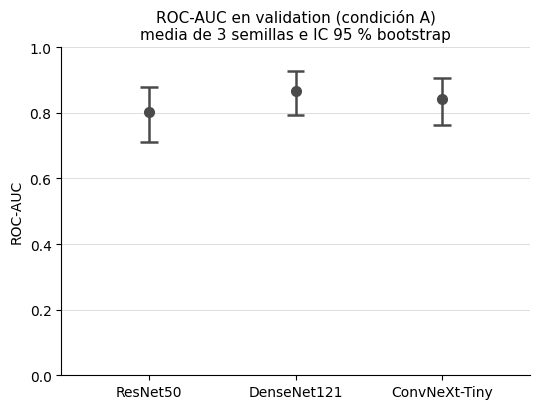

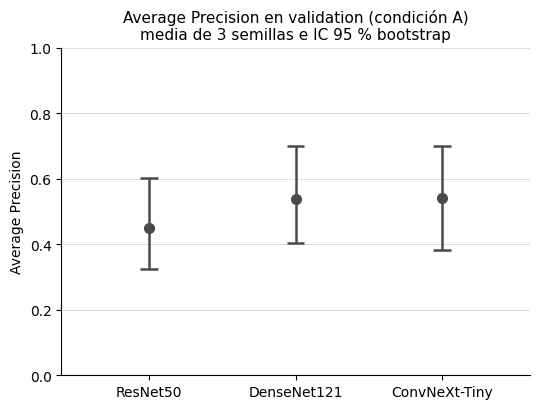

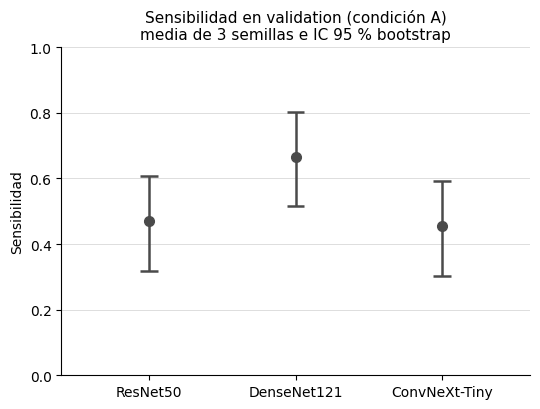

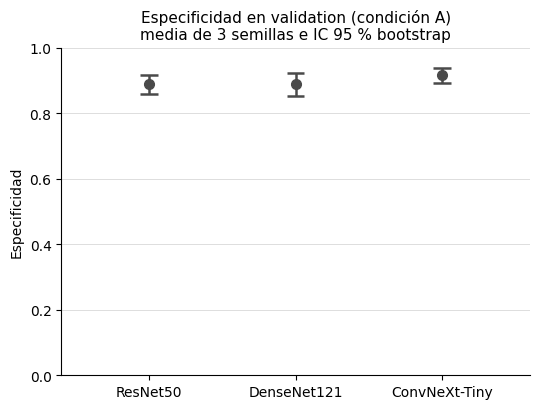

In [18]:
def plot_metric_ci95(metric, filename):
    """Media de las 3 semillas (punto) e IC 95 % bootstrap (barra) por arquitectura."""
    rows = (
        saved_summary[saved_summary["metric"] == metric]
        .set_index("architecture")
        .loc[ARCHS]
    )
    positions = np.arange(len(ARCHS))

    fig, ax = plt.subplots(figsize=(5.5, 4.2))

    ax.vlines(positions, rows["ci95_lower"], rows["ci95_upper"], color=PLOT_COLOR, linewidth=1.8, zorder=2)
    ax.hlines(rows["ci95_lower"], positions - 0.06, positions + 0.06, color=PLOT_COLOR, linewidth=1.8, zorder=2)
    ax.hlines(rows["ci95_upper"], positions - 0.06, positions + 0.06, color=PLOT_COLOR, linewidth=1.8, zorder=2)
    ax.plot(positions, rows["mean"], linestyle="none", marker="o", markersize=7, color=PLOT_COLOR, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels([ARCH_LABELS[arch] for arch in ARCHS])
    ax.set_xlim(-0.6, len(ARCHS) - 0.4)
    ax.set_ylim(0, 1)
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_title(
        f"{METRIC_LABELS[metric]} en validation (condición A)\n"
        "media de 3 semillas e IC 95 % bootstrap",
        fontsize=11,
    )
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


for metric in METRICS:
    plot_metric_ci95(metric, FIGURE_FILES[metric])

### Figura metodológica (ilustrativa)

Se utiliza ROC-AUC y la primera arquitectura del orden fijo (ResNet50) únicamente como ejemplo.

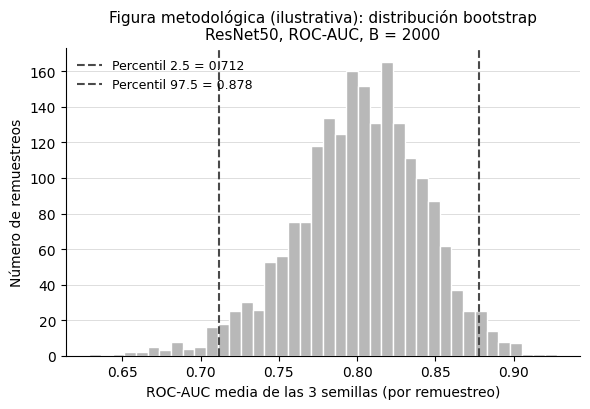

In [19]:
EXAMPLE_ARCH = ARCHS[0]
EXAMPLE_METRIC = "roc_auc"

example_values = saved_bootstrap_means[
    (saved_bootstrap_means["architecture"] == EXAMPLE_ARCH)
    & (saved_bootstrap_means["metric"] == EXAMPLE_METRIC)
]["value"].to_numpy()

assert len(example_values) == N_BOOTSTRAP

lower, upper = np.percentile(example_values, CI_PERCENTILES)

fig, ax = plt.subplots(figsize=(6.0, 4.2))

ax.hist(example_values, bins=40, color="#b8b8b8", edgecolor="white")
ax.axvline(lower, color=PLOT_COLOR, linestyle="--", linewidth=1.5, label=f"Percentil 2.5 = {lower:.3f}")
ax.axvline(upper, color=PLOT_COLOR, linestyle="--", linewidth=1.5, label=f"Percentil 97.5 = {upper:.3f}")

ax.set_xlabel(f"{METRIC_LABELS[EXAMPLE_METRIC]} media de las 3 semillas (por remuestreo)")
ax.set_ylabel("Número de remuestreos")
ax.set_title(
    "Figura metodológica (ilustrativa): distribución bootstrap\n"
    f"{ARCH_LABELS[EXAMPLE_ARCH]}, {METRIC_LABELS[EXAMPLE_METRIC]}, B = {N_BOOTSTRAP}",
    fontsize=11,
)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", color="#dddddd", linewidth=0.7)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "r4_bootstrap_method_example.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
for path in sorted(FIGURES_DIR.glob("*.png")):
    print(path.relative_to(PROJECT_ROOT).as_posix())

results/classification/r4_benchmark/analysis/figures/r4_average_precision_ci95.png
results/classification/r4_benchmark/analysis/figures/r4_bootstrap_method_example.png
results/classification/r4_benchmark/analysis/figures/r4_roc_auc_ci95.png
results/classification/r4_benchmark/analysis/figures/r4_sensitivity_ci95.png
results/classification/r4_benchmark/analysis/figures/r4_specificity_ci95.png
